[*********************100%***********************]  2 of 2 completed


--- PRECIOS DE CIERRE ---
Ticker            AAPL        MSFT
Date                              
2021-06-09  123.920204  243.369507
2021-06-10  122.925964  246.872345
2021-06-11  124.134651  247.496231
2021-06-14  127.185616  249.415619
2021-06-15  126.366829  247.947235


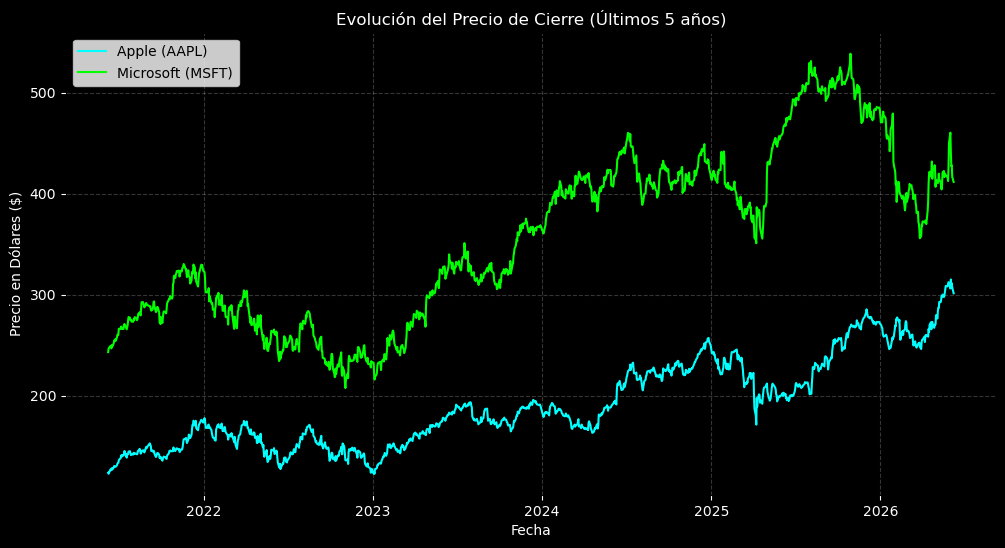


--- RENTABILIDAD DIARIA (VELOCIDAD) ---
Ticker          AAPL      MSFT
Date                          
2021-06-10 -0.008023  0.014393
2021-06-11  0.009833  0.002527
2021-06-14  0.024578  0.007755
2021-06-15 -0.006438 -0.005887
2021-06-16  0.003934 -0.003793


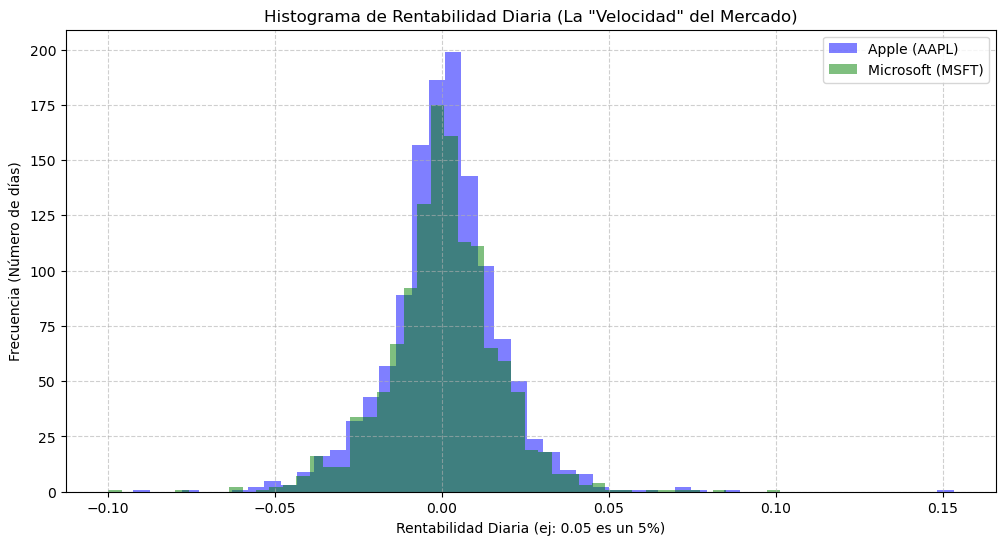


¡Datos guardados con éxito en tu ordenador!


In [2]:
# 1. Importamos las librerías necesarias
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# 2. Descargamos los datos de los últimos 5 años
datos = yf.download(["AAPL", "MSFT"], period="5y")

# datos es la variable que creamos
# yf.download para decirle exactamente la acción que queremos que haga
# () con eso le decimos exactamente qué queremos descargar
# 5y, tiempo 1y (1 año), 1mo (1 mes), 1d (1 día), ytd (1 enero del año actual hasta hoy)
# si lo que quieres es acotar una fecha concreta tienes que poner: datos = yf.download(["AAPL", "MSFT"], start="2023-05-15", end="2023-05-16")
# "AAPL","MSFT" son tickers, ya están guardados con esos nombres en los datos de yfinance

# 3. Nos quedamos solo con el precio de cierre ('Close')
precios_cierre = datos['Close']

# seleccionas una columna directa de los datos descargados

# 4. Mostramos las primeras 5 filas
print("--- PRECIOS DE CIERRE ---")
print(precios_cierre.head())

# .head() es para mostrar las cinco primeras filas desde arriba
# .tail() es para mostrar las últimas cinco filas (las más recientes)

# ==========================================
# GRÁFICA 1: EVOLUCIÓN DEL PRECIO (POSICIÓN)
# ==========================================
plt.figure(figsize=(12, 6), facecolor='black', edgecolor='black')

# .figure, crea el lienzo en blanco donde se va a construir la gráfica
# .figure(figsize=(a,h)) a-ancho, h-alto

# El área del gráfico interior (los ejes)
plt.gca().set_facecolor('black')

plt.plot(precios_cierre.index, precios_cierre['AAPL'], label='Apple (AAPL)', color='cyan') # Cambié a cyan para que resalte más en fondo negro
plt.plot(precios_cierre.index, precios_cierre['MSFT'], label='Microsoft (MSFT)', color='lime') # Cambié a lime para resaltar

# .plot(x,y) dibuja la gráfica en sí

plt.title('Evolución del Precio de Cierre (Últimos 5 años)', color='white')
plt.xlabel('Fecha', color='white')
plt.ylabel('Precio en Dólares ($)', color='white')

# ¡NUEVO! Cambiamos el color de los números de los ejes a blanco para que se vean
plt.tick_params(axis='x', colors='white')
plt.tick_params(axis='y', colors='white')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.3) # Bajé un poco el alpha de la grilla para que moleste menos visualmente
plt.show() 
# IMPORTANTE: Si ejecutas esto fuera de Jupyter, DEBES CERRAR la ventana de la gráfica 1 para que el código siga avanzando.

# ==========================================
# CÁLCULO DE LA "VELOCIDAD" (RENTABILIDAD DIARIA)
# ==========================================
# Usamos .pct_change() para ver qué porcentaje subió o bajó respecto al día anterior
# .dropna() borra el primer día, ya que no tiene un día anterior para compararse
rentabilidad_diaria = precios_cierre.pct_change().dropna()

# dropna() borra los NAN no a number
# dropna(axis=0)- actúa sobre las filas 
# dropna(axis=1)- actúa sobre las columnas

print("\n--- RENTABILIDAD DIARIA (VELOCIDAD) ---")
print(rentabilidad_diaria.head())

# ==========================================
# GRÁFICA 2: HISTOGRAMA DE FRECUENCIAS
# ==========================================
plt.figure(figsize=(12, 6))

# Dibujamos un histograma para cada empresa. 
# "bins=50" divide los datos en 50 barras/categorías
# "alpha=0.5" hace que los colores sean semi-transparentes para que se vean ambas empresas
plt.hist(rentabilidad_diaria['AAPL'], bins=50, alpha=0.5, label='Apple (AAPL)', color='blue')
plt.hist(rentabilidad_diaria['MSFT'], bins=50, alpha=0.5, label='Microsoft (MSFT)', color='green')

# .hist(x,bins=nº,alpha=(0,1),...,...)
# "x" la variable de la que queremos ver la frecuencia
# "bins" nos dice cuantas barras va a tener el histograma
# "alpha" modificamos la transparencia de las barras

plt.title('Histograma de Rentabilidad Diaria (La "Velocidad" del Mercado)')
plt.xlabel('Rentabilidad Diaria (ej: 0.05 es un 5%)')
plt.ylabel('Frecuencia (Número de días)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# ==========================================
# GUARDADO DE DATOS (EXPORTACIÓN)
# ==========================================
# Finalmente, guardamos nuestros datos limpios y calculados en un archivo CSV.
precios_cierre.to_csv("precios_historicos_apple_microsoft.csv")
rentabilidad_diaria.to_csv("rentabilidad_diaria_apple_microsoft.csv")

print("\n¡Datos guardados con éxito en tu ordenador!")